# Exploring and analyzing data.
---
Import data from Kaggle to explore it via the [link.](https://www.kaggle.com/datasets/chebotinaa/fast-food-marketing-campaign-ab-test)

## Introduction:

This dataset represents an **Experimental Study (A/B/C Testing)**. We will start with **Exploratory Data Analysis (EDA)** to observe the initial impact of different treatments (Promotions) on Sales, and to ensure the data is clean and ready for formal statistical testing (CDA)

In [129]:
#impor Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
#read the data WA_Marketing_Campaing.csv
raw_data = pd.read_csv('/home/mona/Downloads/SAD/AAI/student/Data Science/project 1: Fast food marketing/data/raw/WA_Marketing-Campaign.csv')
raw_data

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81
...,...,...,...,...,...,...,...
543,10,Large,919,2,1,4,64.34
544,10,Large,920,14,2,1,50.20
545,10,Large,920,14,2,2,45.75
546,10,Large,920,14,2,3,44.29


---


## Data Exploration

After importing the data, we performed a preliminary check to verify data quality and variable types using `"Info"`. The following outputs illustrate the structural characteristics of the collection:

In [131]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


In [132]:
raw_data.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [133]:
#show all columns of data
raw_data.columns

Index(['MarketID', 'MarketSize', 'LocationID', 'AgeOfStore', 'Promotion',
       'week', 'SalesInThousands'],
      dtype='object')

In [134]:
#Convert all column names to lowercase for consistency and easier access
raw_data.columns = raw_data.columns.str.lower()
print(raw_data.columns)

Index(['marketid', 'marketsize', 'locationid', 'ageofstore', 'promotion',
       'week', 'salesinthousands'],
      dtype='object')


Before beginning the statistical analysis, it is essential to ensure that the data is free of illogical values.

`isnull()` method is used to show if the dataset has any missing or null values

In [135]:
# Check for nulls to ensure data readiness
print(raw_data.isnull().sum())

marketid            0
marketsize          0
locationid          0
ageofstore          0
promotion           0
week                0
salesinthousands    0
dtype: int64


Since the result is (Zero Nulls), we will not need to use processing techniques such as deletion `dropna` or substitution `fillna` with the average of values, and we will move directly to the visual analysis stage.

​such as a revenue shortfall in the area of ​​sales, sales figures cannot be negative.

In [136]:
# # Counting the number of records containing sales less than zero
raw_data.columns = raw_data.columns.str.strip()
mask = raw_data['salesinthousands'] < 0

# Display the negative sales
print(f"nigative salse = {mask.sum()}.")

nigative salse = 0.


---


## Searching for relationships between data

After ensuring the cleanliness of the data, we now move on to extracting statistical indicators that summarize the behavior of the numerical variables in the group.

In [137]:
raw_data.describe()

,marketid,locationid,ageofstore,promotion,week,salesinthousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


In [138]:
# Evaluating marketing campaigns "sales in thousands"
raw_data['salesinthousands'].describe()

count    548.000000
mean      53.466204
std       16.755216
min       17.340000
25%       42.545000
50%       50.200000
75%       60.477500
max       99.650000
Name: salesinthousands, dtype: float64

In [139]:
# Distribution & Frequency
raw_data['promotion'].value_counts()

promotion
3    188
2    188
1    172
Name: count, dtype: int64

In [140]:
# display the mean value of salse for each promotion
raw_data.columns = raw_data.columns.str.strip()
raw_data.groupby('promotion')['salesinthousands'].mean()


promotion
1    58.099012
2    47.329415
3    55.364468
Name: salesinthousands, dtype: float64

---


## Data Visualization

We visually represent and analyze data using the **seaborn**

([<matplotlib.axis.XTick at 0x71dcf7df87f0>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

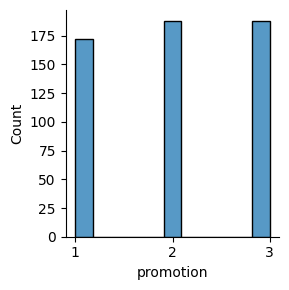

In [141]:
# Representing sales figures in a histograp
sns.displot(
 raw_data,
 kind='hist',
 x='promotion' ,
 aspect= 1 ,
height=3
)
plt.xticks([1,2,3])


In [142]:
# Comparing sales with market size
market_summary = raw_data.groupby('marketsize')['salesinthousands'].mean().sort_values(ascending=False)
market_summary

marketsize
Large     70.116726
Small     57.409333
Medium    43.985344
Name: salesinthousands, dtype: float64

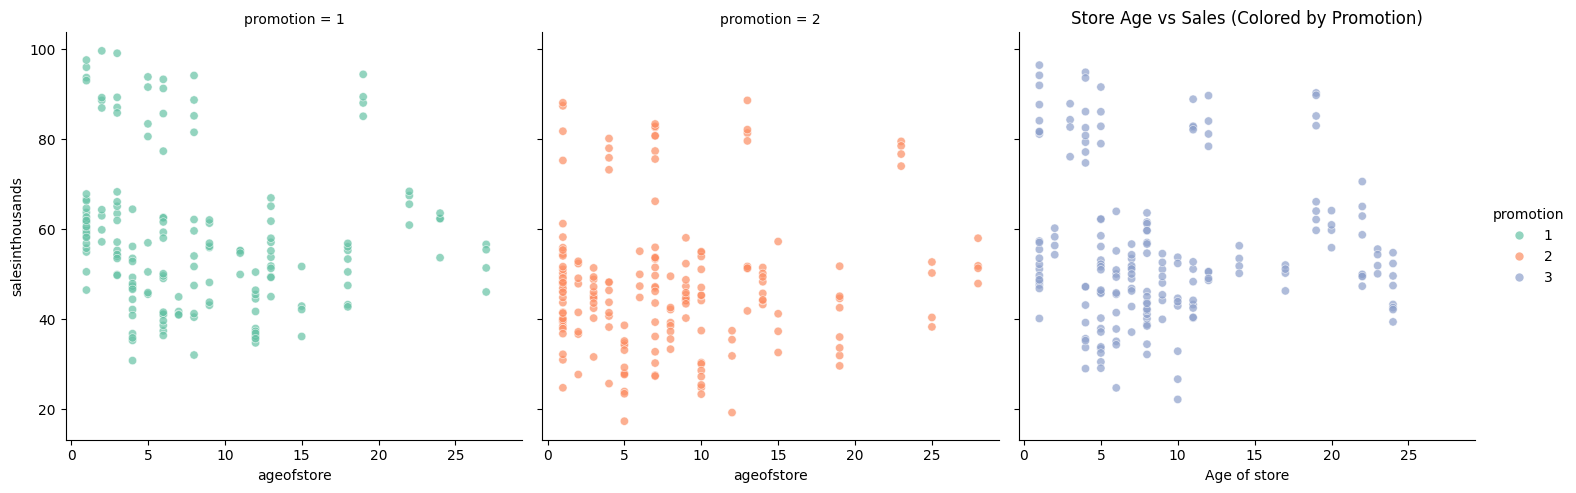

In [143]:
# Exploring the relationship between store age and sales
sns.relplot(
    data=raw_data, 
    x='ageofstore', 
    y='salesinthousands', 
    col='promotion',  
    hue='promotion',   
    palette='Set2', 
    kind='scatter',
    alpha=0.7
)
plt.title('Store Age vs Sales (Colored by Promotion)')

plt.xlabel( 'Age of store')
plt.ylabel('Sales in thousands')
plt.show()

Text(0.5, 1.0, 'Comparison of Sales Performance across Marketing Campaigns')

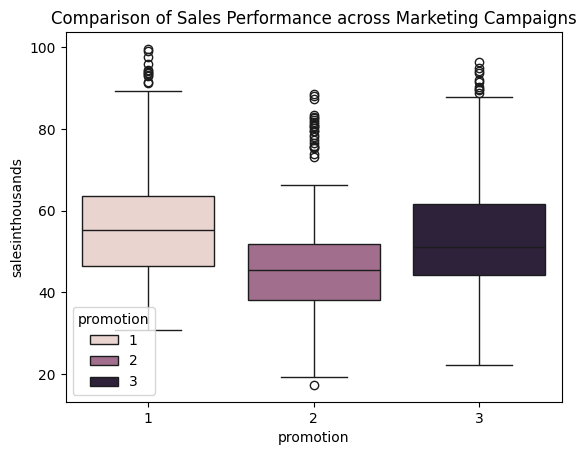

In [144]:
sns.boxplot(data=raw_data, x= 'promotion',
            y='salesinthousands',
            hue='promotion'
            )
plt.title('Comparison of Sales Performance across Marketing Campaigns') 


"Based on the fund's chart, **Campaign 1** is statistically the most successful because it achieves the highest median sales. Although **Campaign 3** performs well and is competitive, Campaign 1 has proven its ability to reach record sales levels (highest extreme values), making it the best option for maximizing profits."

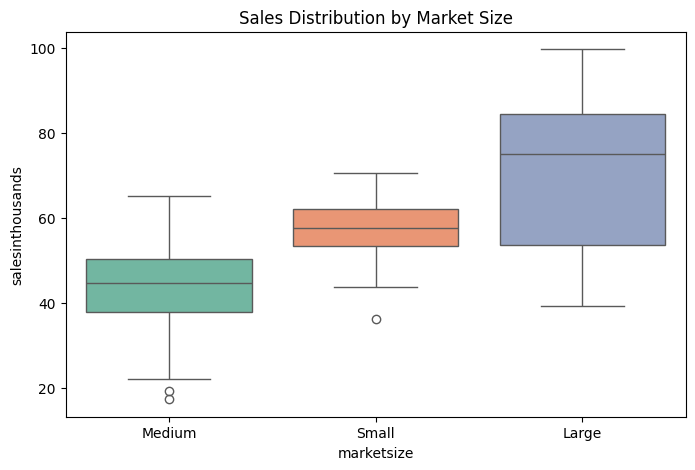

In [145]:
plt.figure(figsize=(8,5))
sns.boxplot(data=raw_data,
             x='marketsize',
             y='salesinthousands',
             hue='marketsize',
             palette='Set2')
plt.title('Sales Distribution by Market Size')
plt.show()

Text(0.5, 1.0, 'Promotion Performance by Market Size')

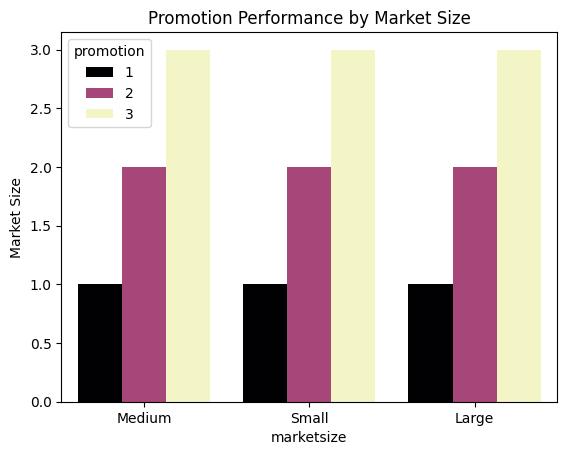

In [146]:
sns.barplot(data=raw_data, x='marketsize',y='promotion',hue='promotion', palette='magma')
plt.ylabel('Market Size')
plt.title('Promotion Performance by Market Size')


---
## Summary: 
We explored, presented, and theoretically analyzed the data, and theoretically it appears that the sales of the third campaign are greater, but we need a statistical test (linear discrimination analysis) to confirm this (CDA).
